# Squeezed Chirp

*What the Noise Remembers · Recover — Moth Hack 2026, Challenge 10 (Quantum-native 2):
a Python notebook showing how we used the Atlas API to build a workflow that makes media.*

On 14 September 2015 both LIGO detectors recorded **GW150914**, the first gravitational wave ever
observed: two black holes merging about 410 Mpc away. In the detectors the signal swept upwards from
about 35 to 250 Hz in a fraction of a second, a "chirp" (Abbott et al., PRL 116, 061102, 2016).

LIGO now hears further by **squeezing light**. Quantum noise in the laser has two parts (quadratures)
whose uncertainties trade against each other: you can make one smaller only by making the other larger.
Squeezed light reduces the phase-quadrature noise (shot noise, which dominates at high frequency) and
pays for it with more amplitude-quadrature noise (radiation pressure, which dominates at low frequency).
Since the fourth observing run, a 300 m **filter cavity** rotates the squeezing with frequency so each
band gets the quadrature it needs. Ganapathy et al. (Phys. Rev. X 13, 041021, 2023) report noise reduced by
4.0 dB at Hanford and 5.8 dB at Livingston, and a 15–18 % longer detection range.

This notebook builds a playful **analogy** to that trade. We take the real chirp's spectrogram, blur it
with a quantum circuit (Atlas `blur-core-v1`) whose blur strength is set **separately on the time axis
and the frequency axis at a fixed product**, and measure and listen to what each "squeeze" does to the
chirp's ridge.

**Workflow:** GWOSC strain → whiten → bandpass 20–500 Hz → STFT grid → `blur-core-v1` × 6 through
the Atlas API → ridge widths → Griffin-Lim WAVs → ledger.

> **Honesty box: this is an analogy to squeezing, not squeezed light.**
> * `blur-core-v1` runs a quantum circuit on **Atlas's classical statevector simulator** (no QPU).
>   Each job used an **18-qubit** register (9 + 9), which the engine itself reports.
> * The "squeeze" is a pair of blur strengths `[s_time, s_freq]` with `s_time × s_freq = 0.25`.
>   It is not a quadrature of light; no quantum noise is reduced and no detection is improved.
> * The fixed product is a product of *rotation strengths*. The measured widths do **not** keep a fixed
>   product (Step 6), and a **classical** Gaussian blur shows the same qualitative trade-off. Nothing here
>   claims a quantum advantage.
> * Every classical step is labelled **CLASSICAL**. Strain data: GWOSC, CC BY 4.0.
> * We aimed for 24 qubits, but the API's measured limits cap a real 2-D grid at 18 (Step 3).
> * With `MOTH_FREEZE=1` this notebook replays the 6 cached jobs and submits nothing new.

In [1]:
# Setup. Atlas client with this piece's credit cap; every new job is ledgered in cache/ledger.jsonl.
import os, sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, Audio, display

HERE = Path.cwd()
ROOT = HERE.parent.parent
sys.path[:0] = [str(ROOT), str(HERE)]
from atlas.client import Atlas, AtlasError
import chirp, analysis
from run_blur import SafeAtlas, job_plan, params_for, unpack, N_T, N_F, QMAX

FREEZE = os.environ.get("MOTH_FREEZE") == "1"
a = SafeAtlas(piece="10-squeezed-chirp", credit_cap=12)   # stock client; one-shot POST to avoid duplicate paid jobs
cm = analysis.wing_cmap()
plt.rcParams.update({"figure.dpi": 90, "axes.grid": False})

def table(rows, cols):
    head = "| " + " | ".join(cols) + " |\n|" + "---|" * len(cols) + "\n"
    return Markdown(head + "\n".join("| " + " | ".join(str(r.get(c, "")) for c in cols) + " |" for r in rows))

print(f"MOTH_FREEZE={FREEZE}  ledgered spend for {a.piece}: {a.spent():g} of {a.credit_cap:g} credits")

MOTH_FREEZE=True  ledgered spend for 10-squeezed-chirp: 8 of 12 credits


## Step 1 · Fetch the real strain (CLASSICAL)

The `gwosc` package locates the GW150914 event files (catalog GWTC-1-confident, v3): 32 s of H1 and L1
strain at 4096 Hz, as HDF5. We read them with `h5py` (gwpy does not install on this machine). Files are
cached in `data/` with their SHA-256, so later runs are offline. Licence: CC BY 4.0, stated on
https://gwosc.org/data/ and the event page.

In [2]:
from fetch_data import fetch
sources = fetch()                       # downloads only if data/ is empty
display(table([{"detector": d, **{k: s[k] for k in ("file", "bytes", "licence")}, "sha256": s["sha256"][:16] + "…",
                "url": s["url"]} for d, s in sources.items()], ["detector", "file", "bytes", "sha256", "licence", "url"]))
x, fs, t0 = chirp.load("H1")
print(f"H1: {len(x)} samples at {fs:.0f} Hz from GPS {t0:.0f} ({len(x)/fs:.0f} s); merger near GPS {chirp.T_MERGER}")

| detector | file | bytes | sha256 | licence | url |
|---|---|---|---|---|---|
| H1 | H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5 | 1040781 | c5ea87beced5094b… | CC BY 4.0 (https://gwosc.org/data/) | https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5 |
| L1 | L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5 | 1007262 | 9d65bde82f7ec035… | CC BY 4.0 (https://gwosc.org/data/) | https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5 |

H1: 131072 samples at 4096 Hz from GPS 1126259447 (32 s); merger near GPS 1126259462.422


## Step 2 · Whiten and bandpass (CLASSICAL)

Divide by the amplitude spectral density (Welch, 4 s segments) so the noise is flat, then a zero-phase
4th-order Butterworth bandpass, 20–500 Hz, then band-limited upsampling ×4. L1 saw the wave about 7 ms
before H1 and with the opposite sign: our own cross-correlation peaks at −7.3 ms, sign-flipped.

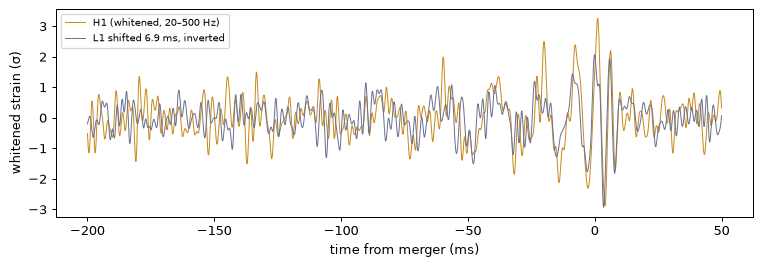

In [3]:
yh, fsu, th = chirp.prepared("H1")
yl, _, tl = chirp.prepared("L1")
fig, ax = plt.subplots(figsize=(10, 3))
m = (th > chirp.T_MERGER - 0.20) & (th < chirp.T_MERGER + 0.05)
ax.plot((th[m] - chirp.T_MERGER) * 1e3, yh[m], lw=0.8, color="#C98A1E", label="H1 (whitened, 20–500 Hz)")
ml = (tl + chirp.L1_SHIFT > chirp.T_MERGER - 0.20) & (tl + chirp.L1_SHIFT < chirp.T_MERGER + 0.05)
ax.plot((tl[ml] + chirp.L1_SHIFT - chirp.T_MERGER) * 1e3, -yl[ml], lw=0.8, color="#6B7390", label="L1 shifted 6.9 ms, inverted")
ax.set_xlabel("time from merger (ms)"); ax.set_ylabel("whitened strain (σ)"); ax.legend(fontsize=8)
plt.show()

## Step 3 · The spectrogram grid, and why it has 18 qubits (CLASSICAL)

A Gaussian-window STFT (σ = 12 ms) evaluated on **257 time frames × 257 frequencies**
(−0.30 to +0.10 s around merger; 20–500 Hz linear). H1 power and time-aligned L1 power are averaged,
then quantised to integers 0–999. `blur-core-v1` pads each axis to the next power of two, so a
257 × 257 grid runs on a 512 × 512 register: **9 + 9 = 18 qubits**. A quarter of the register's grid
points carry data; the rest is zero padding the engine adds, which also gives the blur room to spread.

We tried bigger first, and measured each limit:

| grid | qubits | what happened | cost |
|---|---|---|---|
| 4096 × 4096 | 24 | request body 47.7 MB, rejected `413`: `limit=1048576 bytes` | free (`probe_payload.py`) |
| 2048 × 2048 | 22 | body ≈ 12 MB, over the same 1 MiB limit (measured size, not sent) | free |
| 640 × 640 | 20 | body fits (0.89 MiB), job computed "20-qubit grid", then **failed** `TMPRL1103`: the ~8 MB JSON result exceeds Atlas's internal 2 MB payload limit | 2 credits (2 failed jobs) |
| **257 × 257** | **18** | body 0.2 MB, result ≈ 1.4 MB: **completed** | 1 credit per job |

A 2-D grid needs more than 2¹⁸ values for 20 qubits (513 × 513 at minimum), and its result would not
fit, so 18 is the most a real 2-D grid can use here.

grid (257, 257), values 0..999, request body 0.19 MB, register 18 qubits


| grid | qubits | body_mb | status | body |
|---|---|---|---|---|
| [4096, 4096] | 24 | 47.68 | 413 | {"$schema":"https://api.mothquantum.com/schemas/ErrorModel.json","title":"Request Entity Too Large","status":413,"detail":"request body is too large limit=1048576 bytes"} |

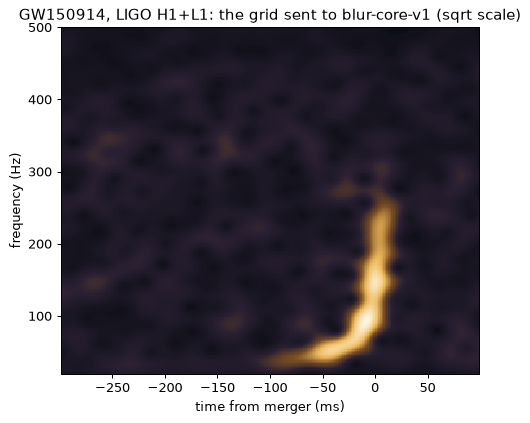

In [4]:
P, tt, ff = chirp.spectrogram(N_T, N_F)
G, top = chirp.quantise(P, QMAX)
assert np.array_equal(G, np.load("out/grid_input.npy")), "grid differs from the one sent to Atlas"
body = json.dumps({"params": params_for(G, job_plan()[0])}, separators=(",", ":"))
q = int(np.ceil(np.log2(N_T)) + np.ceil(np.log2(N_F)))
print(f"grid {G.shape}, values 0..{G.max()}, request body {len(body)/1e6:.2f} MB, register {q} qubits")
display(table([{**r, "body": r.get("body", "").strip()[:170]} for r in json.load(open("out/probes.json"))],
              ["grid", "qubits", "body_mb", "status", "body"]))

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.sqrt(G).T, origin="lower", aspect="auto", cmap=cm, interpolation="nearest",
          extent=[tt[0]*1e3, tt[-1]*1e3, ff[0], ff[-1]])
ax.set_xlabel("time from merger (ms)"); ax.set_ylabel("frequency (Hz)")
ax.set_title("GW150914, LIGO H1+L1: the grid sent to blur-core-v1 (sqrt scale)")
plt.show()

## Step 4 · Read the engine's schema before calling it

Never guess parameter names. `strength` takes one number per axis; `reach = 0` keeps the blur local;
`max_qubits` is a safety cap (we pass the ceiling, 24; the grid's shape decides the 18 actually used).
Under `MOTH_FREEZE=1` the notebook reads the copy saved from `GET /engines/blur-core-v1`.

In [5]:
if FREEZE or not os.environ.get("MOTH_API_KEY") and not (ROOT / ".env").exists():
    schema = json.load(open("engine_schema.json", encoding="utf-8"))
else:
    schema = a.get("/engines/blur-core-v1")
props = schema["params_schema"]["properties"]
display(table([{"param": k, "default": v.get("default"), "max": v.get("maximum", ""),
                "description": v["description"].split("\n")[0][:110]} for k, v in props.items()],
              ["param", "default", "max", "description"]))
print("credits per run:", schema["credits_per_run"])

| param | default | max | description |
|---|---|---|---|
| axes | None |  | Which axes of `values` to blur along. `null` (default) blurs every axis. E.g. for a 2-D grid, `[0]` blurs only |
| max_qubits | 20 | 24 | Safety cap on the total number of qubits `values`'s shape is allowed to require. A 1024x1024 2-D grid costs 20 |
| reach | 0 | 1 | Controls how far from its original position a value can be affected by the blur: |
| shots | None |  | If given, the grid is recovered from this many simulated projective measurements, introducing shot noise. If o |
| strength | 0.5 |  | Strength of the effect, which controls the rotation applied to each qubit: |
| style | x |  | Quantum gate(s) used to apply the effect: any non-empty combination of the letters `x`, `y`, each selecting a  |
| values | None |  | An arbitrarily nested list of non-negative numbers. The nesting depth is the grid's dimensionality: a flat lis |

credits per run: 1


## Step 5 · Six real jobs through the Atlas API (QUANTUM CIRCUIT · Atlas statevector simulator)

Five squeeze ratios on the constant-product curve `s_time × s_freq = 0.25`, plus an isotropic control
that passes one scalar `strength = 0.5` (the engine's own isotropic path). `a.run()` submits the job,
polls it, and caches the result in `cache/blur-core-v1/`; re-running is free and offline.

In [6]:
plan = job_plan()
outs, rows, jobs = {}, [], {}
status = json.load(open("out/job_status.json"))
for job in plan:
    rec = a.run("blur-core-v1", params_for(G, job), timeout=1800)
    A, meta = unpack(rec["response"]["result"])
    assert np.allclose(A, np.load(f"out/{job['name']}.npy"), atol=1e-3)
    outs[job["name"]] = A
    jobs[job["name"]] = {**job, "status": "completed", "job_id": rec["job_id"]}
    rows.append({"job": job["name"], "label": job["label"], "strength": job["strength"],
                 "engine says": status[job["name"]]["progress"]["detail"], "job_id": f"`{rec['job_id']}`"})
display(table(rows, ["job", "label", "strength", "engine says", "job_id"]))
d = np.abs(outs["iso_control"] - outs["r1"]).max()
print(f"isotropic control vs per-axis [0.5, 0.5]: max |difference| = {d:g}")

| job | label | strength | engine says | job_id |
|---|---|---|---|---|
| iso_control | isotropic control (scalar strength) | 0.5 | Recovered 18-qubit grid from measurement | `7c8255b6-77d1-45a6-ad27-9ee4dd40c8f5` |
| r0p25 | s_time/s_freq = 0.25 | [0.25, 1.0] | Recovered 18-qubit grid from measurement | `6f52a515-c8e0-4ec9-8765-ecf2733b7144` |
| r0p5 | s_time/s_freq = 0.5 | [0.3536, 0.7071] | Recovered 18-qubit grid from measurement | `e02daa4b-5158-4d3d-9dfe-84987c63e716` |
| r1 | s_time/s_freq = 1 | [0.5, 0.5] | Recovered 18-qubit grid from measurement | `6fdf4b45-f942-4fda-a98f-c8a16d596dc0` |
| r2 | s_time/s_freq = 2 | [0.7071, 0.3536] | Recovered 18-qubit grid from measurement | `179bb106-df50-43ea-8f0c-8e3f0eabf1f0` |
| r4 | s_time/s_freq = 4 | [1.0, 0.25] | Recovered 18-qubit grid from measurement | `c6ebc23e-e8b0-4cd6-8903-f78c61e7023d` |

isotropic control vs per-axis [0.5, 0.5]: max |difference| = 0


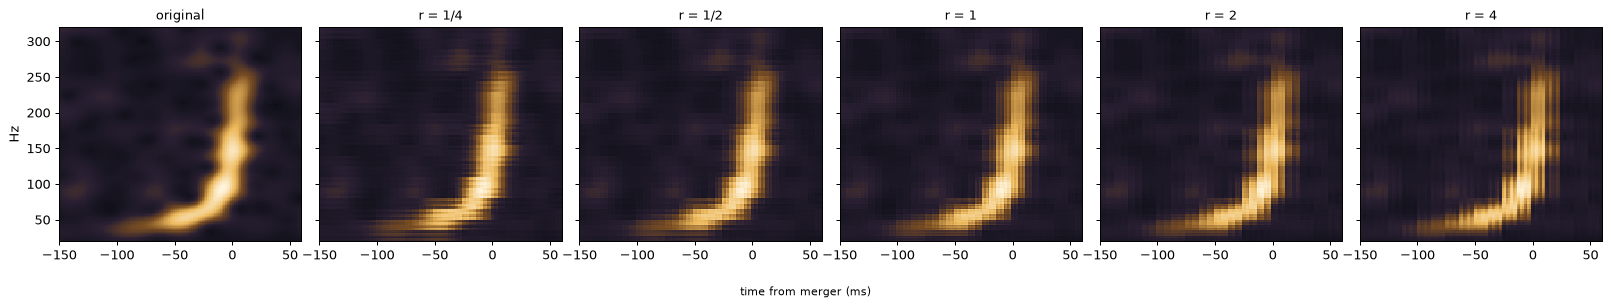

In [7]:
order = ["r0p25", "r0p5", "r1", "r2", "r4"]
fig, axs = plt.subplots(1, 6, figsize=(18, 3.4), sharey=True)
for ax_, n in zip(axs, ["original"] + order):
    A = G if n == "original" else outs[n]
    ax_.imshow(np.sqrt(A).T, origin="lower", aspect="auto", cmap=cm, vmin=0, vmax=np.sqrt(G.max()),
               interpolation="nearest", extent=[tt[0]*1e3, tt[-1]*1e3, ff[0], ff[-1]])
    ax_.set_xlim(-150, 60); ax_.set_ylim(20, 320); ax_.set_title(analysis.LABEL[n], fontsize=10)
axs[0].set_ylabel("Hz"); fig.supxlabel("time from merger (ms)", fontsize=9)
plt.tight_layout(); plt.show()

## Step 6 · Measure the ridge (CLASSICAL)

The chirp is shallow early on and nearly vertical near merger. So the **time-width** is the RMS width of
time profiles at fixed frequency across the steep part (90–220 Hz), and the **frequency-width** is the
RMS width of frequency profiles at fixed time across the shallow part (−90 to −20 ms). Both are measured
around the same ridge track (taken from the original grid) for every version, after removing each
profile's median floor, and averaged with the ridge's power as weight.

| version | strength | time-width (ms) | Δ time | freq-width (Hz) | Δ freq | product (ms·Hz) |
|---|---|---|---|---|---|---|
| original | – | 8.696 | +0.0 % | 11.523 | +0.0 % | 100.2 |
| r = 1/4 | [0.25, 1.0] | 8.996 | +3.5 % | 13.173 | +14.3 % | 118.5 |
| r = 1/2 | [0.3536, 0.7071] | 9.124 | +4.9 % | 12.623 | +9.5 % | 115.2 |
| r = 1 | [0.5, 0.5] | 9.360 | +7.6 % | 12.243 | +6.3 % | 114.6 |
| r = 2 | [0.7071, 0.3536] | 9.714 | +11.7 % | 12.006 | +4.2 % | 116.6 |
| r = 4 | [1.0, 0.25] | 10.226 | +17.6 % | 11.846 | +2.8 % | 121.1 |
| isotropic control | 0.5 | 9.360 | +7.6 % | 12.243 | +6.3 % | 114.6 |

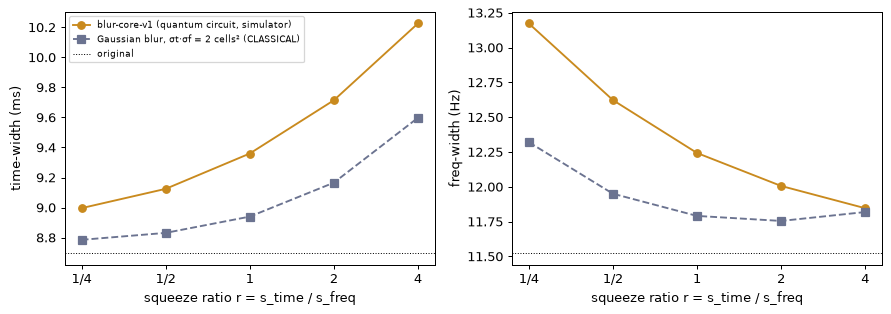

In [8]:
grids = {"original": G, **outs}
widths, track = analysis.all_widths(G, tt, ff, grids, jobs)
o = widths["versions"]["original"]
wrows = []
for n in ["original"] + order + ["iso_control"]:
    w = widths["versions"][n]
    wrows.append({"version": analysis.LABEL[n], "strength": w.get("strength", "–"),
                  "time-width (ms)": f"{w['time_width_ms']:.3f}", "Δ time": f"{100*(w['time_width_ms']/o['time_width_ms']-1):+.1f} %",
                  "freq-width (Hz)": f"{w['freq_width_hz']:.3f}", "Δ freq": f"{100*(w['freq_width_hz']/o['freq_width_hz']-1):+.1f} %",
                  "product (ms·Hz)": f"{w['time_width_ms']*w['freq_width_hz']:.1f}"})
display(table(wrows, list(wrows[0])))

ratios = [0.25, 0.5, 1, 2, 4]
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
for ax_, k, unit in [(axs[0], "time_width_ms", "ms"), (axs[1], "freq_width_hz", "Hz")]:
    ax_.plot(ratios, [widths["versions"][n][k] for n in order], "o-", color="#C98A1E", label="blur-core-v1 (quantum circuit, simulator)")
    ax_.plot(ratios, [widths["classical"][f"{r:g}"][k] for r in ratios], "s--", color="#6B7390", label="Gaussian blur, σt·σf = 2 cells² (CLASSICAL)")
    ax_.axhline(o[k], color="k", lw=0.8, ls=":", label="original")
    ax_.set_xscale("log", base=2); ax_.set_xticks(ratios, ["1/4", "1/2", "1", "2", "4"])
    ax_.set_xlabel("squeeze ratio r = s_time / s_freq"); ax_.set_ylabel(f"{k.split('_')[0]}-width ({unit})")
axs[0].legend(fontsize=7); plt.tight_layout(); plt.show()

**Does the trend depend on how we measure?** Re-measure with narrower and wider profile windows.

In [9]:
rb = []
for key, vals in widths["robustness"].items():
    rb.append({"window": key, **{analysis.LABEL[n]: f"{v['time_width_ms']:.2f} ms / {v['freq_width_hz']:.2f} Hz" for n, v in vals.items()}})
display(table(rb, list(rb[0])))

| window | original | r = 1/4 | r = 1/2 | r = 1 | r = 2 | r = 4 |
|---|---|---|---|---|---|---|
| half_t=20ms,half_f=30Hz | 8.12 ms / 10.29 Hz | 8.32 ms / 11.97 Hz | 8.40 ms / 11.45 Hz | 8.54 ms / 11.07 Hz | 8.74 ms / 10.82 Hz | 9.02 ms / 10.64 Hz |
| half_t=30ms,half_f=40Hz | 8.70 ms / 11.52 Hz | 9.00 ms / 13.17 Hz | 9.12 ms / 12.62 Hz | 9.36 ms / 12.24 Hz | 9.71 ms / 12.01 Hz | 10.23 ms / 11.85 Hz |
| half_t=40ms,half_f=60Hz | 9.08 ms / 13.85 Hz | 9.35 ms / 15.39 Hz | 9.48 ms / 14.89 Hz | 9.73 ms / 14.58 Hz | 10.10 ms / 14.45 Hz | 10.63 ms / 14.43 Hz |

## Play with it · ipywidgets

**Squeeze explorer** (real engine outputs): slide the squeeze ratio, switch between the blurred grid, the
original, and the change, and move the two cuts to see the ridge's time and frequency profiles widen
or narrow. **Classical sandbox**: the same trade with a classical Gaussian blur, computed live, so you can
see what does not need a quantum circuit. (Sliders need a running kernel; the static figures above show
the same data.)

In [10]:
import ipywidgets as W
from scipy.ndimage import gaussian_filter

r_sl = W.SelectionSlider(options=[("1/4", "r0p25"), ("1/2", "r0p5"), ("1", "r1"), ("2", "r2"), ("4", "r4")],
                         value="r4", description="squeeze r", continuous_update=False)
view = W.ToggleButtons(options=["blurred", "original", "change"], value="blurred", description="show")
fcut = W.FloatSlider(value=150, min=90, max=220, step=2, description="cut at f (Hz)", continuous_update=False)
tcut = W.FloatSlider(value=-50, min=-90, max=-20, step=1, description="cut at t (ms)", continuous_update=False)

def explore(name, mode, fc, tc):
    A = outs[name]; w = widths["versions"][name]
    fi, ti = int(np.argmin(abs(ff - fc))), int(np.argmin(abs(tt * 1e3 - tc)))
    fig, axs = plt.subplots(1, 3, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1.2, 1, 1]})
    ext = [tt[0]*1e3, tt[-1]*1e3, ff[0], ff[-1]]
    if mode == "change":
        Dl = (A - G).T; lim = np.abs(Dl).max()
        axs[0].imshow(Dl, origin="lower", aspect="auto", cmap="PuOr_r", vmin=-lim, vmax=lim, extent=ext, interpolation="nearest")
    else:
        axs[0].imshow(np.sqrt(G if mode == "original" else A).T, origin="lower", aspect="auto", cmap=cm, vmin=0,
                      vmax=np.sqrt(G.max()), extent=ext, interpolation="nearest")
    axs[0].axhline(ff[fi], color="w", lw=0.6, ls="--"); axs[0].axvline(tt[ti]*1e3, color="w", lw=0.6, ls="--")
    axs[0].set_xlim(-150, 60); axs[0].set_ylim(20, 320); axs[0].set_title(f"{analysis.LABEL[name]}  strength {jobs[name]['strength']}")
    axs[1].plot(tt*1e3, G[:, fi], color="#6B7390", label="original"); axs[1].plot(tt*1e3, A[:, fi], color="#C98A1E", label="blurred")
    axs[1].set_xlim(-60, 40); axs[1].set_title(f"time profile at {ff[fi]:.0f} Hz"); axs[1].legend(fontsize=8)
    axs[2].plot(ff, G[ti], color="#6B7390"); axs[2].plot(ff, A[ti], color="#C98A1E")
    axs[2].set_xlim(20, 160); axs[2].set_title(f"frequency profile at {tt[ti]*1e3:.0f} ms")
    plt.tight_layout(); plt.show()
    print(f"ridge time-width {w['time_width_ms']:.2f} ms ({100*(w['time_width_ms']/o['time_width_ms']-1):+.1f} %)   "
          f"freq-width {w['freq_width_hz']:.2f} Hz ({100*(w['freq_width_hz']/o['freq_width_hz']-1):+.1f} %)   "
          f"job {jobs[name]['job_id']}")

ui = W.VBox([W.HBox([r_sl, view]), W.HBox([fcut, tcut])])
display(ui, W.interactive_output(explore, {"name": r_sl, "mode": view, "fc": fcut, "tc": tcut}))

Output()

In [11]:
c_r = W.FloatLogSlider(value=4, base=2, min=-3, max=3, step=0.5, description="σt / σf", continuous_update=False)
c_p = W.FloatSlider(value=2.0, min=0.5, max=16, step=0.5, description="σt·σf (cells²)", continuous_update=False)

def sandbox(r, p):
    B = analysis.classical_reference(G, r, p)
    w = chirp.ridge_widths(B, track, tt, ff)
    fig, ax_ = plt.subplots(figsize=(5, 3.6))
    ax_.imshow(np.sqrt(B).T, origin="lower", aspect="auto", cmap=cm, extent=[tt[0]*1e3, tt[-1]*1e3, ff[0], ff[-1]], interpolation="nearest")
    ax_.set_xlim(-150, 60); ax_.set_ylim(20, 320); ax_.set_title("CLASSICAL Gaussian blur (not an engine output)", fontsize=9)
    plt.show()
    print(f"σt = {np.sqrt(p*r):.2f} cells, σf = {np.sqrt(p/r):.2f} cells -> time-width {w['time_width_ms']:.2f} ms, "
          f"freq-width {w['freq_width_hz']:.2f} Hz, product {w['time_width_ms']*w['freq_width_hz']:.1f}")

display(W.HBox([c_r, c_p]), W.interactive_output(sandbox, {"r": c_r, "p": c_p}))

Output()

## Step 7 · Hear each version: Griffin-Lim resynthesis (CLASSICAL)

A spectrogram has no phase, so Griffin & Lim's algorithm (IEEE Trans. ASSP 32(2), 236–243, 1984) iterates
STFT ↔ inverse STFT to find a signal whose magnitude matches it. For listening, each grid is mapped
**8× slower and 4× higher** (35–250 Hz becomes 140–1000 Hz) from −160 ms to +100 ms, the same noise gate
(the original grid's 95th percentile) is subtracted from every version, every version starts from the
same random phase (seed 0, 80 iterations), and one common gain is applied, so differences you hear come
from the grids.

In [12]:
audio = analysis.render_audio(G, tt, ff, grids)
for n in ["original"] + order:
    print(f"{analysis.LABEL[n]:10s}  {audio[n]['file']}  {audio[n]['seconds']} s")
    display(Audio(filename=audio[n]["file"]))

original    out/audio/original.wav  2.072 s


r = 1/4     out/audio/r0p25.wav  2.072 s


r = 1/2     out/audio/r0p5.wav  2.072 s


r = 1       out/audio/r1.wav  2.072 s


r = 2       out/audio/r2.wav  2.072 s


r = 4       out/audio/r4.wav  2.072 s


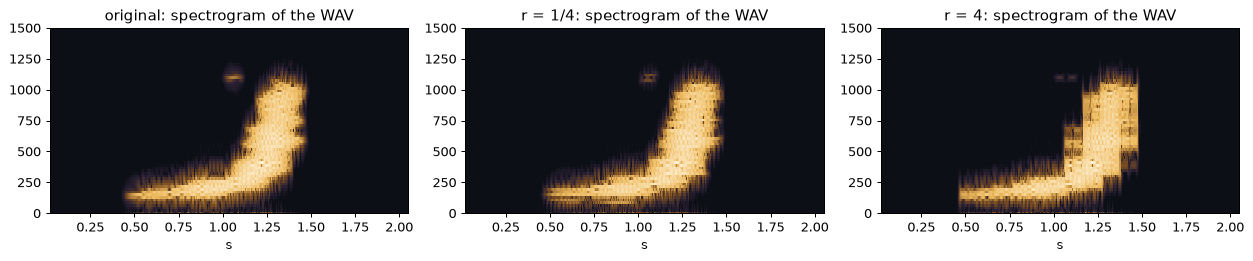

In [13]:
import wave
from scipy import signal as sg
fig, axs = plt.subplots(1, 3, figsize=(14, 3))
for ax_, n in zip(axs, ["original", "r0p25", "r4"]):
    with wave.open(audio[n]["file"]) as wv:
        xa = np.frombuffer(wv.readframes(wv.getnframes()), "<i2") / 32768
    f_, t_, S = sg.spectrogram(xa, chirp.AUDIO_FS, nperseg=1024, noverlap=896)
    ax_.pcolormesh(t_, f_, 10*np.log10(S + 1e-12), shading="auto", vmin=-90, cmap=cm)
    ax_.set_ylim(0, 1500); ax_.set_title(f"{analysis.LABEL[n]}: spectrogram of the WAV"); ax_.set_xlabel("s")
plt.tight_layout(); plt.show()

## Step 8 · Ledger: every credit this piece spent

Read straight from `cache/ledger.jsonl` (written by the Atlas client at each submission), joined with
each job's status. The two failed 20-qubit jobs cost credits and produced nothing; they are listed, not
hidden.

In [14]:
led = [json.loads(l) for l in open(ROOT / "cache" / "ledger.jsonl", encoding="utf-8") if '"10-squeezed-chirp"' in l]
done = {j["job_id"]: j for j in json.load(open("out/jobs.json"))}
failed = {j["job_id"]: j for j in json.load(open("out/failed_jobs.json"))}
lrows = []
for e in led:
    j = done.get(e["job_id"]) or failed.get(e["job_id"]) or {}
    lrows.append({"job_id": f"`{e['job_id']}`", "engine": e["engine"], "credits": e["credits"],
                  "grid": "×".join(map(str, j.get("grid", []))), "qubits": j.get("qubits", ""),
                  "strength": j.get("strength", ""),
                  "status": j.get("status", "?") + (f" ({j['error']['message'][:60]})" if j.get("error") else "")})
display(table(lrows, ["job_id", "engine", "credits", "grid", "qubits", "strength", "status"]))
print(f"total ledgered: {a.spent():g} credits of a {a.credit_cap:g}-credit cap; "
      f"{sum(r['status'].startswith('completed') for r in lrows)} completed jobs used")

| job_id | engine | credits | grid | qubits | strength | status |
|---|---|---|---|---|---|---|
| `43503eaa-594b-493c-a914-8491c9f116db` | blur-core-v1 | 1.0 | 640×640 | 20 | 0.5 | failed ([TMPRL1103] Attempted to upload payloads with size that exce) |
| `02b057fb-6aae-4279-b456-d2801753f44d` | blur-core-v1 | 1.0 | 640×640 | 20 | 0.5 | failed ([TMPRL1103] Attempted to upload payloads with size that exce) |
| `7c8255b6-77d1-45a6-ad27-9ee4dd40c8f5` | blur-core-v1 | 1.0 | 257×257 | 18 | 0.5 | completed |
| `6f52a515-c8e0-4ec9-8765-ecf2733b7144` | blur-core-v1 | 1.0 | 257×257 | 18 | [0.25, 1.0] | completed |
| `e02daa4b-5158-4d3d-9dfe-84987c63e716` | blur-core-v1 | 1.0 | 257×257 | 18 | [0.3536, 0.7071] | completed |
| `6fdf4b45-f942-4fda-a98f-c8a16d596dc0` | blur-core-v1 | 1.0 | 257×257 | 18 | [0.5, 0.5] | completed |
| `179bb106-df50-43ea-8f0c-8e3f0eabf1f0` | blur-core-v1 | 1.0 | 257×257 | 18 | [0.7071, 0.3536] | completed |
| `c6ebc23e-e8b0-4cd6-8903-f78c61e7023d` | blur-core-v1 | 1.0 | 257×257 | 18 | [1.0, 0.25] | completed |

total ledgered: 8 credits of a 12-credit cap; 6 completed jobs used


## What we found, and what it does not mean

* **The trade is real in this analogy.** Moving the squeeze ratio from 1/4 to 4 moves blur from the
  frequency axis to the time axis: the ridge's time-width grows from 9.00 to 10.23 ms (original 8.70 ms)
  while its frequency-width shrinks from 13.17 to 11.85 Hz (original 11.52 Hz). The trend holds for all
  three measurement windows.
* **The product of widths is not constant.** Fixing `s_time × s_freq` fixes a product of rotation
  strengths, not of widths: the measured product is lowest at r = 1 (114.6 ms·Hz) and rises at both ends
  (118.5 and 121.1). An ideal squeezed state stays at the minimum uncertainty product; this blur does not.
* **The isotropic control matches r = 1 exactly** (max difference 0): a per-axis `[0.5, 0.5]` and a
  scalar `0.5` give identical outputs, so the per-axis code path adds nothing of its own and the
  differences between ratios come from the anisotropy.
* **The register shows through.** The blurred grids carry blocky stripes along the more strongly blurred
  axis: the Gray-coded qubit grid of the encoding, not anything in the gravitational wave.
* **No quantum advantage.** A classical anisotropic Gaussian blur gives the same qualitative trade. The
  circuit is a creative tool here, run on a classical simulator.

### References
* B. P. Abbott et al. (LIGO Scientific and Virgo Collaborations), "Observation of Gravitational Waves from a Binary Black Hole Merger", *Phys. Rev. Lett.* 116, 061102 (2016).
* D. Ganapathy et al. (LIGO O4 Detector Collaboration), "Broadband Quantum Enhancement of the LIGO Detectors with Frequency-Dependent Squeezing", *Phys. Rev. X* 13, 041021 (2023).
* R. Abbott et al. (LIGO, Virgo), "Open data from the first and second observing runs of Advanced LIGO and Advanced Virgo", *SoftwareX* 13, 100658 (2021).
* D. Griffin and J. Lim, "Signal estimation from modified short-time Fourier transform", *IEEE Trans. ASSP* 32(2), 236–243 (1984).
* J. R. Wootton, "Procedural generation using quantum computation", *Proc. FDG 2020* (Quantum Blur).

*This research has made use of data obtained from the Gravitational Wave Open Science Center (gwosc.org), a
service of the LIGO Scientific Collaboration, the Virgo Collaboration, and KAGRA.* The full acknowledgement
text is in `CREDITS.md`.